In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015 (1).csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
# Missing values
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [3]:
df.fillna(df.median(), inplace=True)

In [4]:
# duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [5]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

In [6]:
selected_features = df[['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol', 'Age', 'HeartDiseaseorAttack', 'PhysHlth', 'MentHlth', 'Income']]
selected_features.head()

,GenHlth,HighBP,BMI,DiffWalk,HighChol,Age,HeartDiseaseorAttack,PhysHlth,MentHlth,Income
0,5.0,1.0,40.0,1.0,1.0,9.0,0.0,15.0,18.0,3.0
1,3.0,0.0,25.0,0.0,0.0,7.0,0.0,0.0,0.0,1.0
2,5.0,1.0,28.0,1.0,1.0,9.0,0.0,30.0,30.0,8.0
3,2.0,1.0,27.0,0.0,0.0,11.0,0.0,0.0,0.0,6.0
4,2.0,1.0,24.0,0.0,1.0,11.0,0.0,0.0,3.0,4.0


In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd
import shap
import matplotlib.pyplot as plt


# Train/Test Split
X = selected_features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
class_weight="balanced"

In [8]:
# Train Logistic Regression Model

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")


# Evaluation
y_pred = log_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression trained successfully!

Accuracy: 0.7175

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     38813
         1.0       0.32      0.75      0.45      7082

    accuracy                           0.72     45895
   macro avg       0.63      0.73      0.63     45895
weighted avg       0.84      0.72      0.75     45895



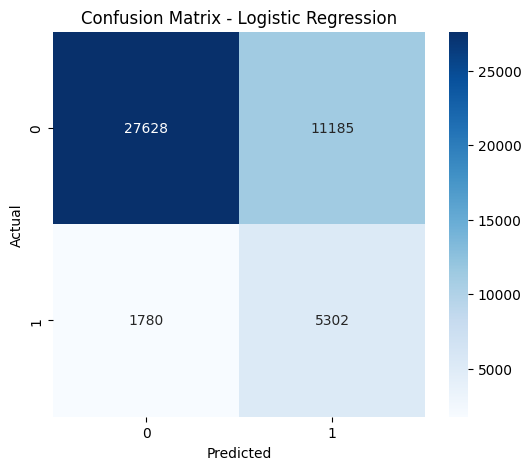

In [9]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

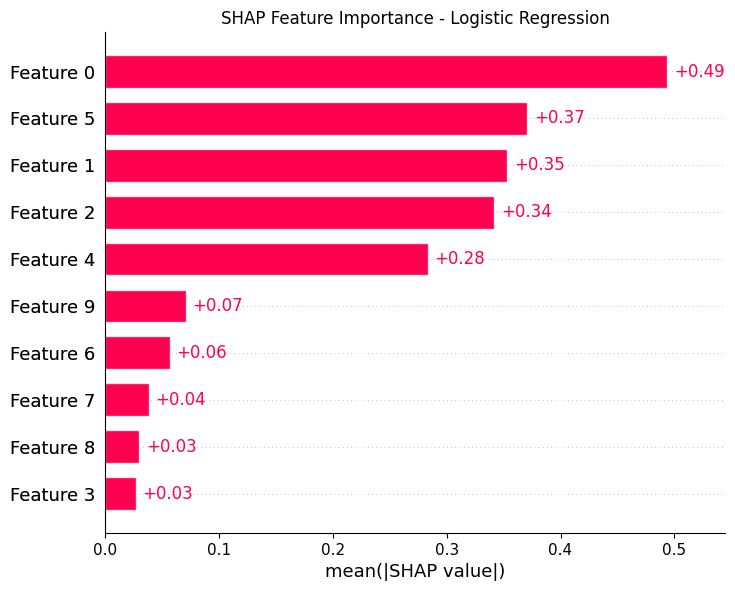

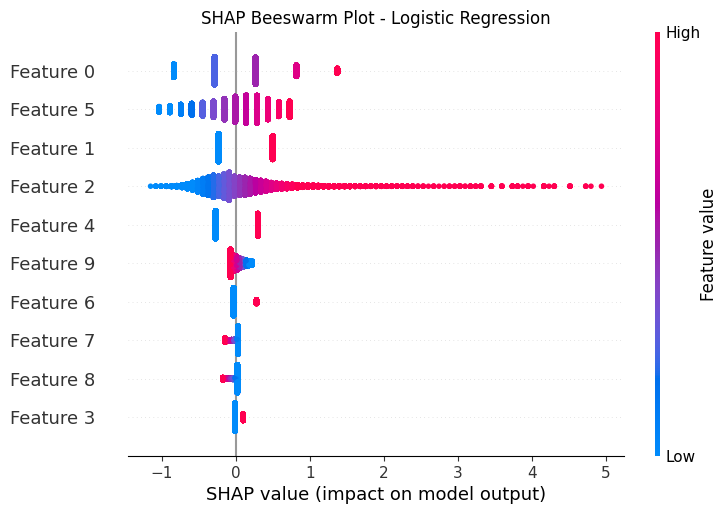

In [10]:
# SHAP

explainer = shap.Explainer(log_model, X_train_scaled)

shap_values = explainer(X_test_scaled)

# SHAP Bar Plot
plt.figure(figsize=(12,6))

shap.plots.bar(shap_values, show=False)

plt.title("SHAP Feature Importance - Logistic Regression")

plt.show()



# SHAP Beeswarm Plot
plt.figure(figsize=(12,6))

shap.plots.beeswarm(shap_values, show=False)

plt.title("SHAP Beeswarm Plot - Logistic Regression")

plt.show()

In [11]:
# LIME
!pip install lime

from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[0],
    log_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=01f470db78d2bcb3d90ef920b0663b3c9eecb3dcd43a973dc8abd30af2db7169
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


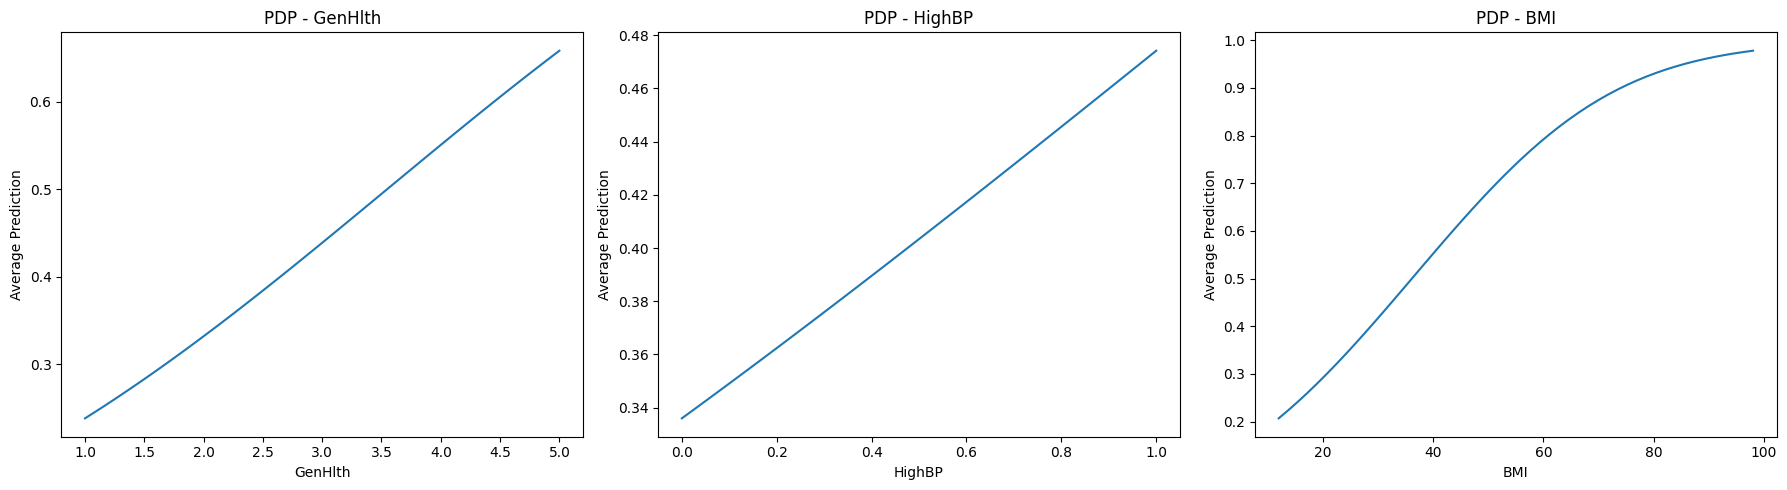

In [20]:
#PDP
import numpy as np
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()

features_to_plot = ['GenHlth', 'HighBP', 'BMI']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for idx, feature in enumerate(features_to_plot):

    values = np.linspace(
        X_train[feature].min(),
        X_train[feature].max(),
        50
    )

    probs = []

    for val in values:

        X_temp = X_train.copy()

        X_temp[feature] = val

        X_temp_scaled = scaler.transform(X_temp)

        prob = log_model.predict_proba(X_temp_scaled)[:,1].mean()

        probs.append(prob)

    axes[idx].plot(values, probs)

    axes[idx].set_title(f"PDP - {feature}")
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Average Prediction")

plt.tight_layout()
plt.show()


Permutation Importance:
                Feature  Importance
0               GenHlth    0.014782
2                   BMI    0.008177
6  HeartDiseaseorAttack    0.000843
9                Income    0.000553
7              PhysHlth    0.000466
8              MentHlth    0.000044
3              DiffWalk    0.000039
4              HighChol   -0.002368
5                   Age   -0.005308
1                HighBP   -0.006556


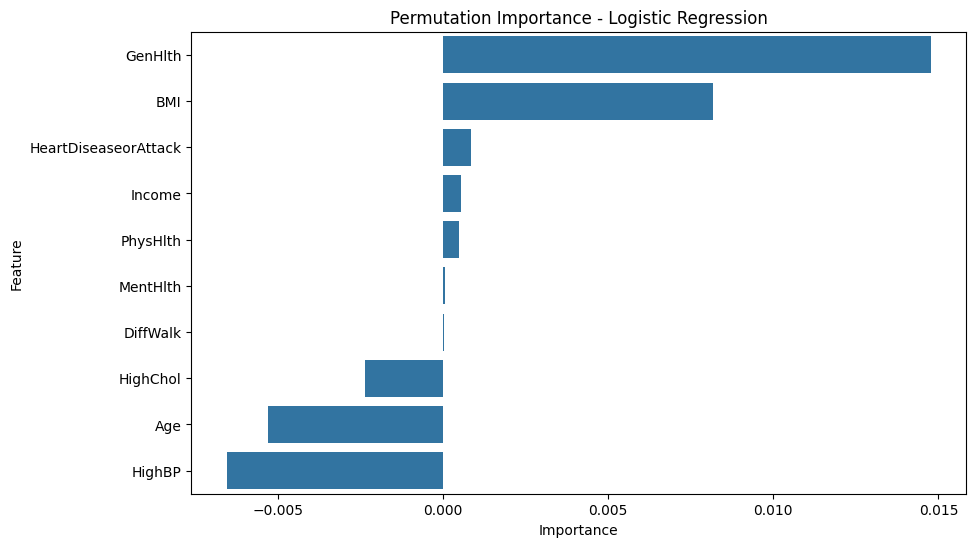

In [21]:
# Permutation Importance
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    log_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nPermutation Importance:")
print(importance_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Importance - Logistic Regression")

plt.show()
